In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset with correct encoding
df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

# Show first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'sales_data_sample.csv'

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [ ]:
total_sales = df["SALES"].sum()
print("Total Sales:", total_sales)

Total Sales: 10032628.85


In [ ]:
top_products = df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)
top_products

,SALES
PRODUCTLINE,
Classic Cars,3919615.66
Vintage Cars,1903150.84
Motorcycles,1166388.34
Trucks and Buses,1127789.84
Planes,975003.57
Ships,714437.13
Trains,226243.47


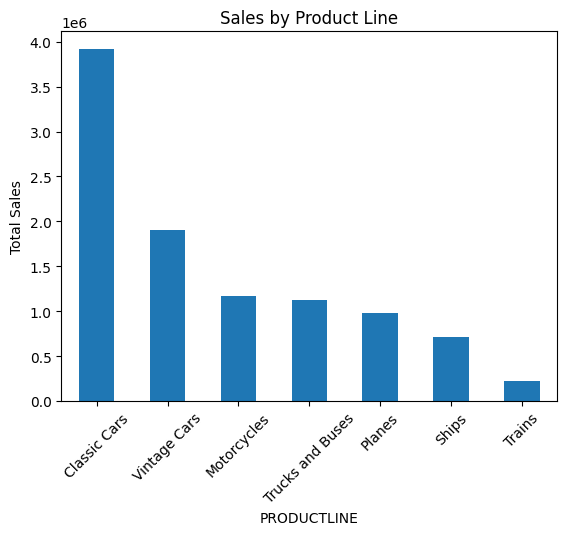

In [ ]:
top_products.plot(kind="bar")
plt.title("Sales by Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

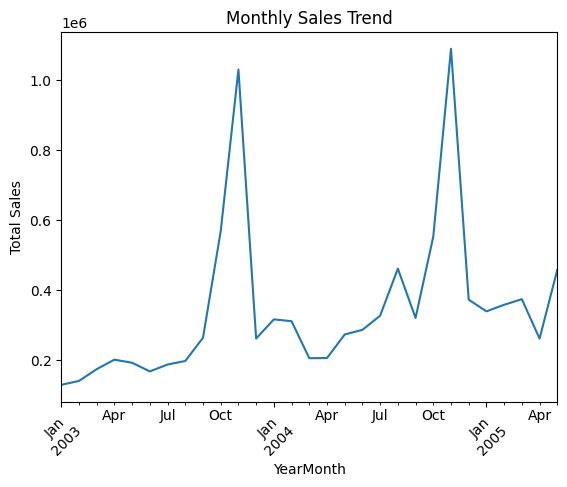

In [ ]:
# Convert ORDERDATE to datetime
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

# Extract Year-Month
df["YearMonth"] = df["ORDERDATE"].dt.to_period("M")

# Group by month
monthly_sales = df.groupby("YearMonth")["SALES"].sum()

# Plot monthly trend
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()